<a href="https://colab.research.google.com/github/JGradone/Topics-Sentinel/blob/main/Rutgers_Topics_in_Marine_Science_Activity_3_Sentinel_Data_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 3 - Sentinel Glider Data Metrics
**2025 Rutgers University Topics in Marine Science**

*Written by Joe Gradone, Rutgers University, February 24, 2025*

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from geopy.distance import geodesic

#geodesic((transect1_ad2cp.start_lon[x],transect1_ad2cp.start_lat[x]),(transect1_ad2cp.end_lon[x],transect1_ad2cp.end_lat[x])).meters

## Load data

In [21]:
## This is a path to where this text file is stored on my GitHub
url = 'https://raw.githubusercontent.com/JGradone/Topics-Sentinel/845495a2a25b95a1ea85315b92880abd67d4fbed/Sentinel_CCBay_Flight_Data.txt'

## Load the text file with the read_csv() function from pandas
df = pd.read_csv(url)
## Reformat time
df['time'] = pd.to_datetime(df['time'])
## Take a peak at what it looks like
df

,time,m_depth,m_pitch,m_roll,c_heading,m_heading,m_lon,m_lat
0,2025-01-19 00:12:21.183000064,0.263165,0.010472,-0.013963,0.000000,3.412119,-70.610592,41.639527
1,2025-01-19 00:12:25.249999872,0.217889,0.005236,-0.008727,0.000000,3.405137,-70.610592,41.639527
2,2025-01-19 00:12:29.316000000,0.308440,0.006981,-0.012217,0.000000,3.410373,-70.610592,41.639527
3,2025-01-19 00:12:33.382999808,0.331078,0.006981,-0.015708,0.000000,3.413864,-70.610592,41.639527
4,2025-01-19 00:12:37.450000128,0.331078,0.001745,-0.008727,0.000000,3.399901,-70.610592,41.639527
...,...,...,...,...,...,...,...,...
1735,2025-01-19 19:16:46.440000000,1.920912,0.572468,-0.047124,3.666229,3.487168,-70.457606,41.821862
1736,2025-01-19 19:16:50.441999872,0.992990,0.563741,-0.045379,3.666406,3.501131,-70.457608,41.821849
1737,2025-01-19 19:16:54.444999936,0.223493,0.403171,-0.040143,3.666535,3.502876,-70.457610,41.821834
1738,2025-01-19 19:16:58.451000064,0.178229,-0.106465,-0.057596,3.666709,3.358013,-70.457610,41.821823


## Group 1: Calculate Horizontal Speed

Horizontal speed is distance/time.

This can be calculated with the position (latitude = m_lat and longitude = m_lon) and time (time).

Distance can be calculated with the geodesic() function you imported in the first step of this notebook.

Below is an example of how to use this function:

In [18]:
## Latitude and longitude of Rutgers campus
RU_lon = -74.4443
RU_lat = 40.4967

## Latitude and longitude of NYC
NYC_lon = -74.0060
NYC_lat = 40.7128

## Calculate the distance between these two points
change_in_distance = geodesic((RU_lat,RU_lon),(NYC_lat,NYC_lon))
## Print it out
change_in_distance

Distance(44.18094099506481)

What are the units of the output above? **Hint:** Use `?geodesic` to ask Python what that function does!

## Now let's calculate horizontal speed of the Sentinel glider

**Hint:** You can get the first and last data points from the glider data dataframe by doing this

```
df.iloc[0]  ## For first point
df.iloc[-1] ## For last point
```

### Bonus! Can you calculate the speed in meters/second?

## Group 2: Calculate Dive/Climb Speed

Dive/climb speed are calculated by doing depth/time.

We need to subset our data set to just a dive or climb to perform this calculation. Here's how to start that process below. Adjust `start_time` and `end_time` to find just one dive or climb and then calculate the speed.

Text(0.5, 0, 'Time')

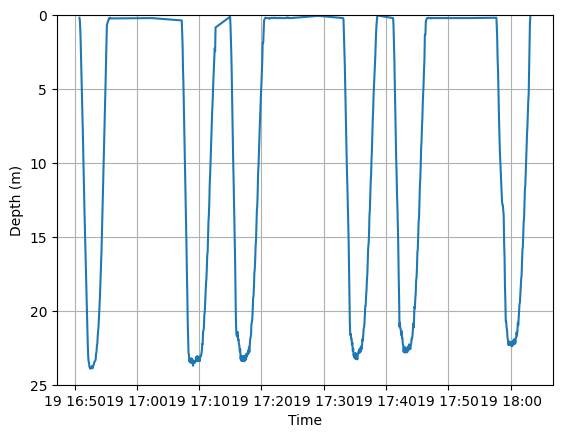

In [59]:
start_time = df.time[648] ## Start point
end_time = df.time[1195] ## End point

subset_df = df[(df.time >= start_time) & (df.time <= end_time)]
plt.plot(subset_df.time,subset_df.m_depth)
plt.ylim(25,0)
plt.grid()
plt.ylabel('Depth (m)')
plt.xlabel('Time')


In [61]:
change_in_depth = subset_df.m_depth.iloc[-1]-subset_df.m_depth.iloc[0] ## end depth minus start depth
change_in_time = (subset_df.time.iloc[-1]-subset_df.time.iloc[0]).seconds
change_in_depth/change_in_time

-1.0422406700550612e-05

## Group 3: Calculate Battery Consumption

In [20]:
df

,time,m_depth,m_pitch,m_roll,c_heading,m_heading,m_lon,m_lat
0,2025-01-19 00:12:21.183000064,0.263165,0.010472,-0.013963,0.000000,3.412119,-70.610592,41.639527
1,2025-01-19 00:12:25.249999872,0.217889,0.005236,-0.008727,0.000000,3.405137,-70.610592,41.639527
2,2025-01-19 00:12:29.316000000,0.308440,0.006981,-0.012217,0.000000,3.410373,-70.610592,41.639527
3,2025-01-19 00:12:33.382999808,0.331078,0.006981,-0.015708,0.000000,3.413864,-70.610592,41.639527
4,2025-01-19 00:12:37.450000128,0.331078,0.001745,-0.008727,0.000000,3.399901,-70.610592,41.639527
...,...,...,...,...,...,...,...,...
1735,2025-01-19 19:16:46.440000000,1.920912,0.572468,-0.047124,3.666229,3.487168,-70.457606,41.821862
1736,2025-01-19 19:16:50.441999872,0.992990,0.563741,-0.045379,3.666406,3.501131,-70.457608,41.821849
1737,2025-01-19 19:16:54.444999936,0.223493,0.403171,-0.040143,3.666535,3.502876,-70.457610,41.821834
1738,2025-01-19 19:16:58.451000064,0.178229,-0.106465,-0.057596,3.666709,3.358013,-70.457610,41.821823
